# **What Does This Dataset Represent?**
The dataset represent land information in saudi Arabia.
Here is the data description:


## **Columns Description**
*   mainlocation:	The main location of the land.
*   sublocation: Indicates the subregion of the location.
*   neighborhood: The neighborhood where the land resides.
*   frontage: The cardinal direction where the land faces the street.
*   purpose: The purpose for land use.
*   streetwidth: The length of the street facing the land in meters.
*   size: The size of the land in meters squared.
*   Pricepm: The price per meters squared.

## **Define the Problem**
*   Regression Problem
*   the target is calculate land price with the foolowing equasion: (price per meters squared) * (size in meters squared).
*   Leakage features: size, Pricepm




# Import Libaries

In [1]:
!pip install catboost
!pip install xgboost
!pip install arabic-reshaper python-bidi

In [2]:
import warnings
# Suppress all warnings
warnings.filterwarnings('ignore')
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, cross_val_predict, cross_validate, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import arabic_reshaper
from bidi.algorithm import get_display


# Start on Explore the data set.

## Read the data set.

In [3]:
path = kagglehub.dataset_download("hussainalqatari/land-market-in-saudi-arabia")

print("Path to dataset files:", path)

dataset = pd.read_csv(path + "/aqardata_2.csv")

Using Colab cache for faster access to the 'land-market-in-saudi-arabia' dataset.
Path to dataset files: /kaggle/input/land-market-in-saudi-arabia


In [4]:
print(dataset.shape)
display(dataset.head(n=20))

(2951, 8)


,mainlocation,sublocation,neighborhood,frontage,purpose,streetwidth,size,Pricepm
0,الرياض,غرب الرياض,حي ظهرة لبن,شمال,سكني,20.0,727,1800
1,بريدة,NaN,حي مشعل,غرب,NaN,15.0,450,950
2,الخبر,NaN,حي الحمرا,غرب,تجاري,100.0,1450,3500
3,الخبر,NaN,حي الحزام الاخضر,شرق,NaN,15.0,440,2700
4,بريدة,NaN,حي الرحاب,جنوب غربي,NaN,40.0,784,950
5,الرياض,شمال الرياض,حي العارض,جنوب,تجاري,60.0,5973,2000
6,جدة,شمال جدة,حي الريان,شرق,سكني,20.0,660,2300
7,سكاكا,NaN,حي مخطط كريم الدرزي,شمال,سكني,15.0,735,219
8,الجموم,NaN,حي النسيم,غرب,NaN,60.0,153500,195
9,المدينة المنورة,NaN,حي الخالدية,شمال غربي,تجاري,40.0,591,5076


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2951 entries, 0 to 2950
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mainlocation  2951 non-null   object 
 1   sublocation   2276 non-null   object 
 2   neighborhood  2951 non-null   object 
 3   frontage      2951 non-null   object 
 4   purpose       2604 non-null   object 
 5   streetwidth   2948 non-null   float64
 6   size          2951 non-null   int64  
 7   Pricepm       2951 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 184.6+ KB


## Processing the data set.

In [6]:
print(dataset.duplicated().sum())

1


In [7]:
dataset = dataset.drop_duplicates()
print(dataset.duplicated().sum())

0


In [8]:
print(dataset.isnull().sum())

mainlocation      0
sublocation     675
neighborhood      0
frontage          0
purpose         347
streetwidth       2
size              0
Pricepm           0
dtype: int64


otption 1: drop all nulls.

In [9]:
dataset1 = dataset.copy()

In [10]:
dataset1 = dataset1.dropna()

In [11]:
dataset1.shape

(2031, 8)

i can't do this option because more than 900 rows will delete and i dont know how importance they are, so i will see how might i handle it.

otption 2:

*    sublocation has many nulls so i desided to drop it.
*   nulls in streetwidth is only 2 values so i will delete it.


*   for purpose i will see how can i handle it

In [12]:
dataset = dataset.drop('sublocation', axis = 1)
dataset.dropna(subset=['streetwidth'], inplace=True)
print(dataset.shape)
display(dataset.head(n=20))

(2948, 7)


,mainlocation,neighborhood,frontage,purpose,streetwidth,size,Pricepm
0,الرياض,حي ظهرة لبن,شمال,سكني,20.0,727,1800
1,بريدة,حي مشعل,غرب,NaN,15.0,450,950
2,الخبر,حي الحمرا,غرب,تجاري,100.0,1450,3500
3,الخبر,حي الحزام الاخضر,شرق,NaN,15.0,440,2700
4,بريدة,حي الرحاب,جنوب غربي,NaN,40.0,784,950
5,الرياض,حي العارض,جنوب,تجاري,60.0,5973,2000
6,جدة,حي الريان,شرق,سكني,20.0,660,2300
7,سكاكا,حي مخطط كريم الدرزي,شمال,سكني,15.0,735,219
8,الجموم,حي النسيم,غرب,NaN,60.0,153500,195
9,المدينة المنورة,حي الخالدية,شمال غربي,تجاري,40.0,591,5076


In [13]:
print(dataset.isnull().sum())

mainlocation      0
neighborhood      0
frontage          0
purpose         347
streetwidth       0
size              0
Pricepm           0
dtype: int64


*   Now try to handel purpose colmun.
*   purpose is obj column.



## find purpose relations

In [14]:
def arabic_text(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

### Categorical vs Numerical
*   size
*   streetwidth
*   Pricepm

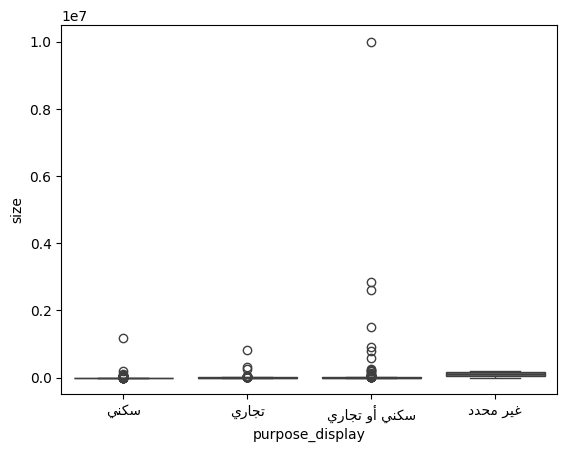

In [15]:
#size
dataset_copy = dataset.copy()

#dataset_copy['purpose_display'] = dataset_copy['purpose'].fillna('').astype(str).apply(arabic_text)
dataset_copy['purpose_display'] = dataset_copy['purpose'].apply(
    lambda x: arabic_text(x) if pd.notna(x) else x
)

sns.boxplot(x='purpose_display', y='size', data=dataset_copy)

plt.show()

In [16]:
size_groupby_purpose = dataset.groupby('purpose')['size'].mean()
size_groupby_purpose

,size
purpose,
تجاري,6944.451220
سكني,2209.008487
سكني أو تجاري,80739.070896
غير محدد,101663.000000


In [17]:
dataset['size'].mean()

np.float64(10410.292740841249)

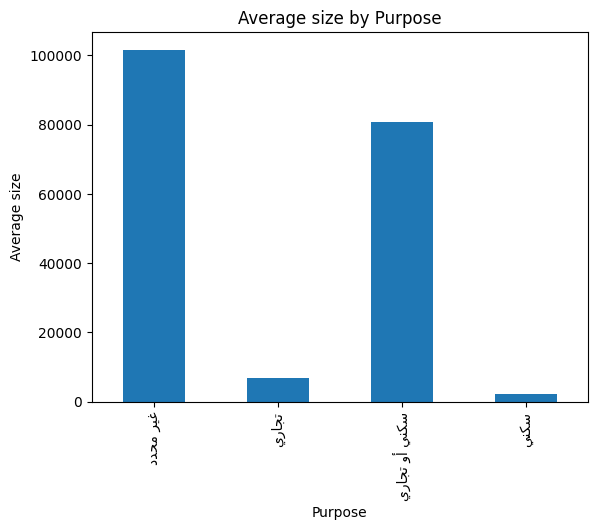

In [18]:
dataset_copy.groupby('purpose_display')['size'].mean().plot(kind='bar')

plt.xlabel("Purpose")
plt.ylabel("Average size")
plt.title("Average size by Purpose")
plt.show()

In [19]:
print(dataset['streetwidth'].mean())
print(dataset['streetwidth'].median())

24.691994572591586
20.0


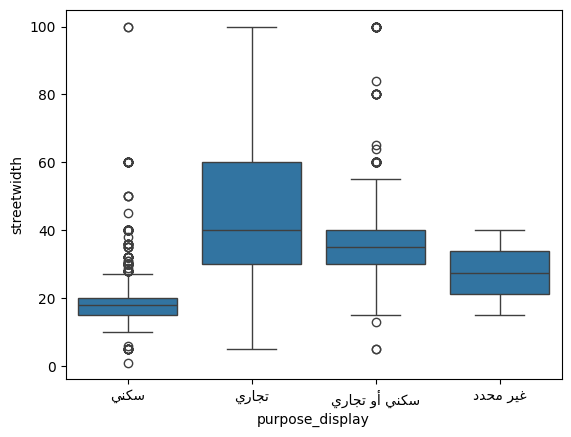

In [20]:
#streetwidth
sns.boxplot(x='purpose_display', y='streetwidth', data=dataset_copy)
plt.show()

In [21]:
dataset['streetwidth'].mean()

np.float64(24.691994572591586)

In [22]:
streetwidth_groupby_purpose = dataset.groupby('purpose')['streetwidth'].mean()
streetwidth_groupby_purpose

,streetwidth
purpose,
تجاري,45.734756
سكني,19.231653
سكني أو تجاري,40.802239
غير محدد,27.500000


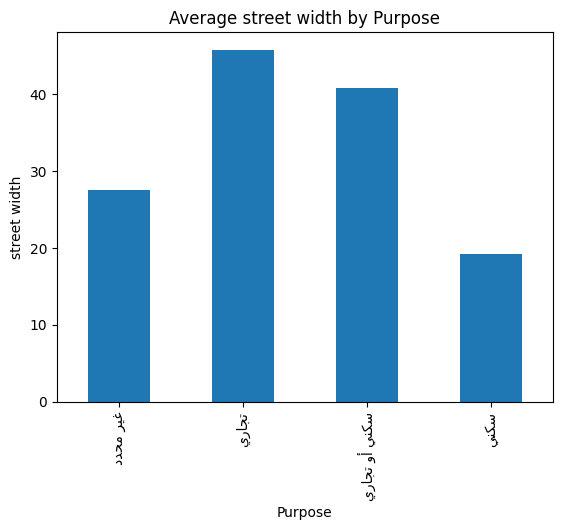

In [23]:
dataset_copy.groupby('purpose_display')['streetwidth'].mean().plot(kind='bar')

plt.xlabel("Purpose")
plt.ylabel("street width")
plt.title("Average street width by Purpose")
plt.show()

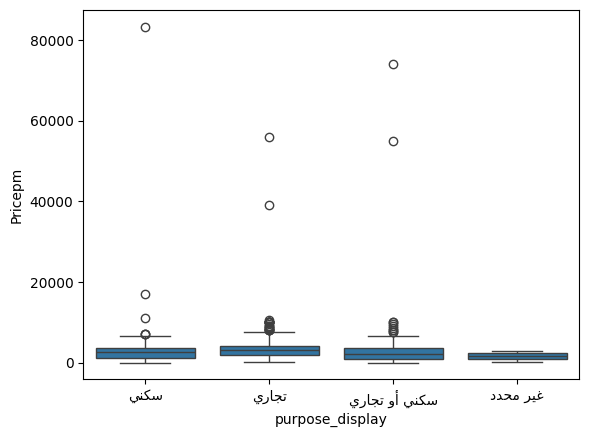

In [24]:
#Pricepm
sns.boxplot(x='purpose_display', y='Pricepm', data=dataset_copy)
plt.show()

In [25]:
#Pricepm
Pricepm_groupby_purpose = dataset.groupby('purpose')['Pricepm'].mean()
Pricepm_groupby_purpose

,Pricepm
purpose,
تجاري,3622.146341
سكني,2531.767848
سكني أو تجاري,2917.335821
غير محدد,1550.000000


In [26]:
dataset['Pricepm'].mean()

np.float64(2625.9158751696064)

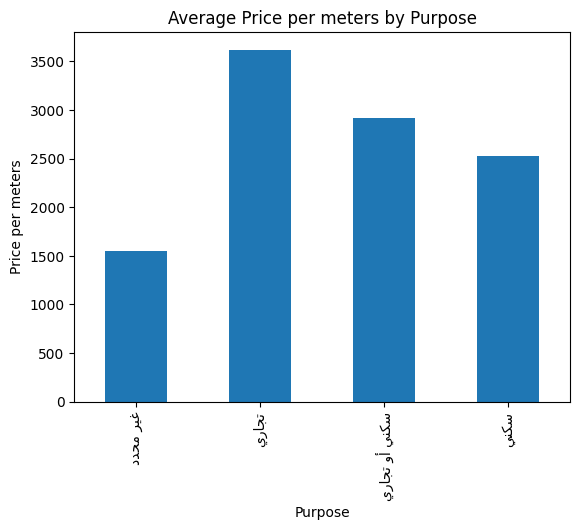

In [27]:
dataset_copy.groupby('purpose_display')['Pricepm'].mean().plot(kind='bar')

plt.xlabel("Purpose")
plt.ylabel("Price per meters")
plt.title("Average Price per meters by Purpose")
plt.show()

streetwidth has a good relation with purpose.

### Categorical vs Categorical
*   mainlocation
*   neighborhood
*   frontage

#### with mainlocation

In [28]:
pd.crosstab(dataset['mainlocation'], dataset['purpose'], normalize='index')

purpose,تجاري,سكني,سكني أو تجاري,غير محدد
mainlocation,,,,
ابها,0.000000,0.500000,0.500000,0.000000
ابو عريش,0.000000,1.000000,0.000000,0.000000
احد رفيده,0.000000,0.800000,0.200000,0.000000
الخبر,0.119266,0.839450,0.041284,0.000000
الخرج,0.125000,0.875000,0.000000,0.000000
الدرعية,0.017241,0.948276,0.034483,0.000000
الدلم,0.500000,0.000000,0.500000,0.000000
الدمام,0.205882,0.588235,0.205882,0.000000
الرس,0.230769,0.461538,0.307692,0.000000


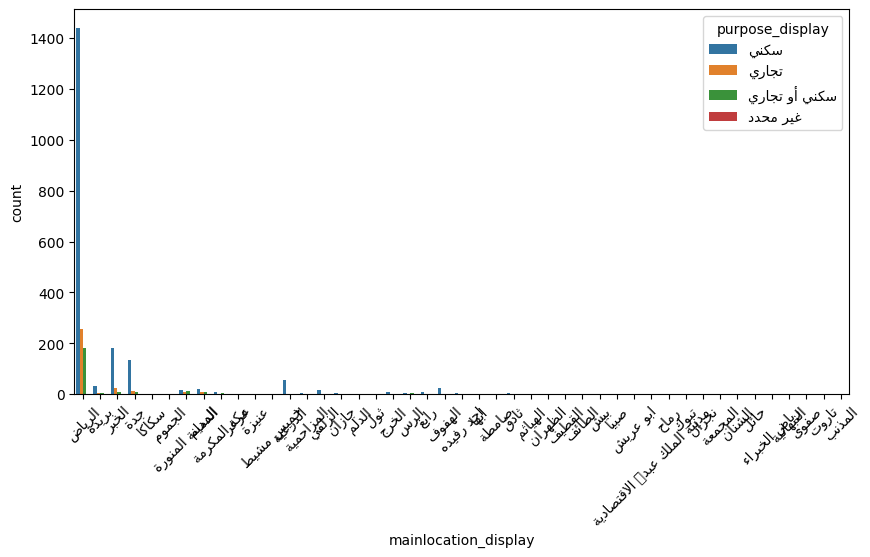

In [29]:
dataset_copy['mainlocation_display'] = dataset_copy['mainlocation'].apply(arabic_text)

plt.figure(figsize=(10,5))
sns.countplot(x="mainlocation_display", hue="purpose_display", data=dataset_copy)
plt.xticks(rotation=45)
plt.show()

#### neighborhood

In [30]:
pd.crosstab(dataset['neighborhood'], dataset['purpose'], normalize='index')

purpose,تجاري,سكني,سكني أو تجاري,غير محدد
neighborhood,,,,
حي ابحر الجنوبية,0.166667,0.666667,0.166667,0.0
حي ابحر الشمالية,0.100000,0.900000,0.000000,0.0
حي ابو بريقاء,1.000000,0.000000,0.000000,0.0
حي ابو كبير,0.000000,0.000000,1.000000,0.0
حي ابو معن,1.000000,0.000000,0.000000,0.0
...,...,...,...,...
حي مشرف,0.000000,1.000000,0.000000,0.0
حي مشرفة,0.000000,1.000000,0.000000,0.0
حي منطقة المرافق,0.000000,0.000000,1.000000,0.0


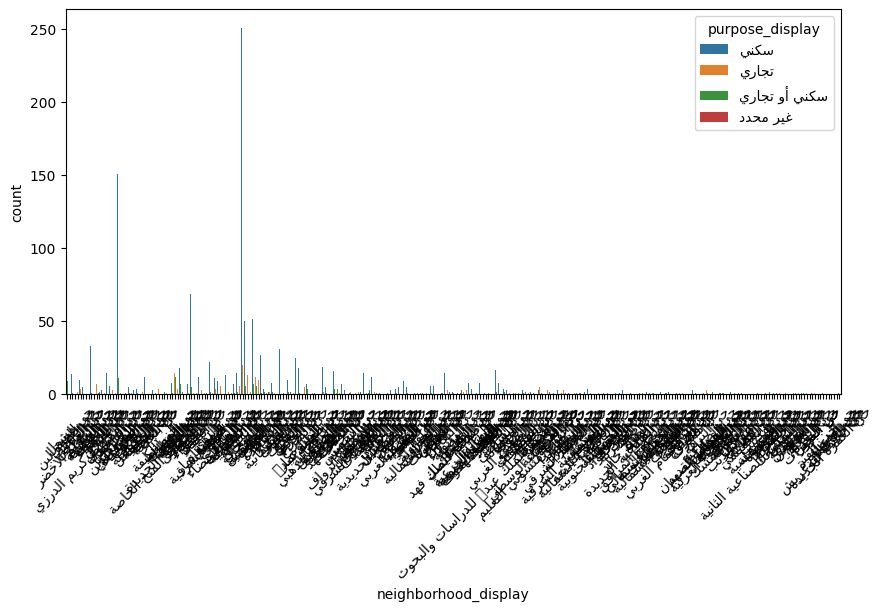

In [31]:
dataset_copy['neighborhood_display'] = dataset_copy['neighborhood'].apply(arabic_text)

plt.figure(figsize=(10,5))
sns.countplot(x="neighborhood_display", hue="purpose_display", data=dataset_copy)
plt.xticks(rotation=45)
plt.show()

I advise you not to see the graph above:/

#### frontage

In [32]:
pd.crosstab(dataset['frontage'], dataset['purpose'], normalize='index')

purpose,تجاري,سكني,سكني أو تجاري,غير محدد
frontage,,,,
3 شوارع,0.209677,0.572581,0.217742,0.000000
4 شوارع,0.140187,0.504673,0.355140,0.000000
جنوب,0.105386,0.822014,0.072600,0.000000
جنوب شرقي,0.146667,0.760000,0.093333,0.000000
جنوب غربي,0.142857,0.722689,0.134454,0.000000
شرق,0.110024,0.811736,0.078240,0.000000
شمال,0.134434,0.804245,0.058962,0.002358
شمال شرقي,0.117021,0.797872,0.085106,0.000000
شمال غربي,0.063291,0.829114,0.107595,0.000000


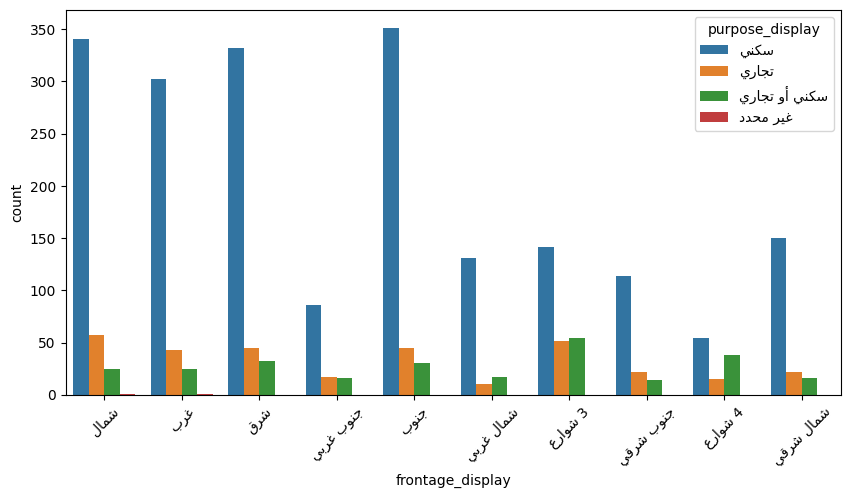

In [33]:
dataset_copy['frontage_display'] = dataset_copy['frontage'].apply(arabic_text)
plt.figure(figsize=(10,5))
sns.countplot(x="frontage_display", hue="purpose_display", data=dataset_copy)
plt.xticks(rotation=45)
plt.show()

####**Final desecion**

Based on statistical analysis and data visualization, it has been concluded that **`streetwidth`** is the most reliable predictor for understanding and imputing missing values in the `purpose` column. The findings are summarized as follows:

**1. Street Width: The Most Decisive Factor**

* The analysis reveals a clear and significant gap in the average street width between residential and commercial properties.
* The average street width for **Commercial** land is approximately **45.7m**, whereas for **Residential** land, it is about **19.2m**.
* This distinct numerical separation makes `streetwidth` an excellent threshold for classifying land use with high confidence.

 **2. Land Size: An Inconclusive Relationship**

* Contrary to initial assumptions, land size did not exhibit a strong correlation or a consistent pattern with the property's purpose.
* Both large residential plots and relatively small commercial plots exist in the dataset, making "Size" an unreliable standalone metric for imputation.

**3. Price per Meter (Pricepm): Geographical Interference**

* The price per square meter is heavily influenced by the **prestige of the neighborhood** and the city rather than the purpose alone.
* **The Challenge:** A residential plot in a high-end district (e.g., in Riyadh) can be significantly more expensive than a commercial plot in a smaller city. This overlap makes `Pricepm` a misleading indicator for determining the purpose.

**4. Location, Neighborhood, and Frontage: Secondary Indicators**

* Features such as `mainlocation`, `neighborhood`, and `frontage` provided mixed results.
* While certain cities show a high density of residential plots, these columns contain high variance and overlapping values, preventing them from being used as a primary standard for classification.

---

**Conclusion:**

The **`streetwidth`** feature will be adopted as the primary logic for handling missing values in the `purpose` column, supplemented by location-based averages to ensure maximum prediction accuracy.


*   mean streetwidth : ~24.7
*   mean streetwidth when purpose = commerical: ~45.7
*   mean streetwidth when purpose = residential: ~19.2
*   mean streetwidth when purpose = residential or commerical: ~40.8



*   if streetwidth < mean_residential then i will fill null with 'سكني'.
*   if streetwidth > mean_commerical then i will fill null with 'تجاري'
*   if  mean_residential > streetwidth < mean_commerical then i will fill null with 'سكني أو تجاري''

In [34]:
mean_commerical = dataset[dataset["purpose"] == "تجاري"]['streetwidth'].mean()
mean_sakani = dataset[dataset["purpose"] == "سكني"]['streetwidth'].mean()
dataset.loc[(dataset['purpose'].isna()) & (dataset['streetwidth'] < mean_sakani), 'purpose'] = 'سكني'
dataset.loc[(dataset['purpose'].isna()) & (dataset['streetwidth'] > mean_commerical), 'purpose'] = 'تجاري'
dataset.loc[(dataset['purpose'].isna()) , 'purpose'] = 'سكني أو تجاري'

In [35]:
dataset.isnull().sum()

,0
mainlocation,0
neighborhood,0
frontage,0
purpose,0
streetwidth,0
size,0
Pricepm,0


# Machine Learning part

In [36]:
models = {
    'linear regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Support Vector Regression (SVR)': SVR(),
    'K-Nearest Neighbors Regression': KNeighborsRegressor(),
    'Random Forests Regressor': RandomForestRegressor(),
    'Gradient Boosting Regressor': GradientBoostingRegressor(),
    'XGBRegressor': XGBRegressor(verbose=0),
    'CatBoost': CatBoostRegressor(verbose=0)
}

## Split the data
i will use to approach, k-folds and train_test_split. then see what give better results.

In [37]:
dataset['land_price'] = dataset['Pricepm']*dataset['size'] #calculate land price, the target
X = dataset.drop(['Pricepm','land_price'], axis=1)
print(X.columns)
y = dataset['land_price']

Index(['mainlocation', 'neighborhood', 'frontage', 'purpose', 'streetwidth',
       'size'],
      dtype='object')


## train test split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = np.log(y_train)
y_test = np.log(y_test)

###one_hot_encoding

In [39]:
#one_hot_encoding
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()
X_train_encoded['streetwidth'] = np.log(X_train_encoded['streetwidth'])
X_test_encoded['streetwidth'] = np.log(X_test_encoded['streetwidth'])
X_train_encoded['size'] = np.log(X_train_encoded['size'])
X_test_encoded['size'] = np.log(X_test_encoded['size'])

X_train_encoded = pd.get_dummies(X_train_encoded)
X_test_encoded = pd.get_dummies(X_test_encoded)

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

1 ) Training: linear regression
1 : Training: linear regression
MAE =  0.24630224981498638
RMSE = 0.42813204639162666
R^2 = 0.8998143901533638


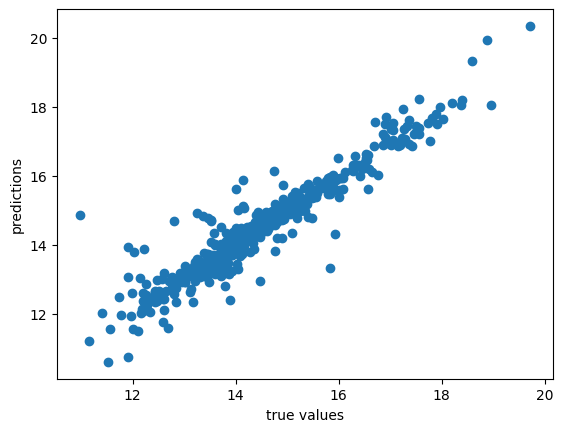

-------------------------------------------------------

2 ) Training: Ridge Regression
2 : Training: Ridge Regression
MAE =  0.25060553198219154
RMSE = 0.41571016885101125
R^2 = 0.9055436479502432


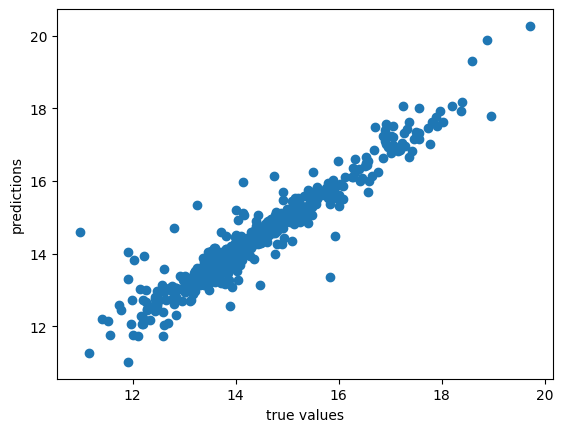

-------------------------------------------------------

3 ) Training: Lasso Regression
3 : Training: Lasso Regression
MAE =  1.0078370425595293
RMSE = 1.3223957240577098
R^2 = 0.04418741323835762


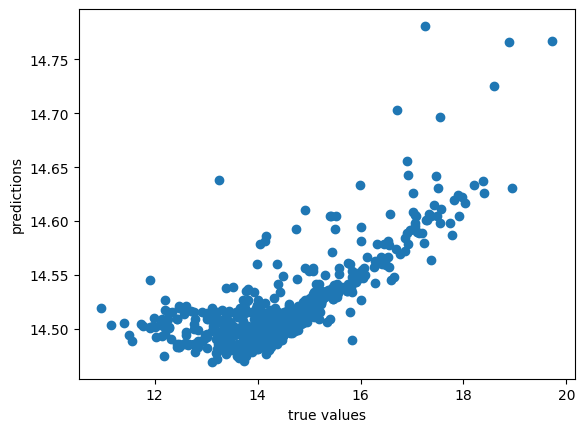

-------------------------------------------------------

4 ) Training: Support Vector Regression (SVR)
4 : Training: Support Vector Regression (SVR)
MAE =  0.30619061239941475
RMSE = 0.5264440577348848
R^2 = 0.8485203375858507


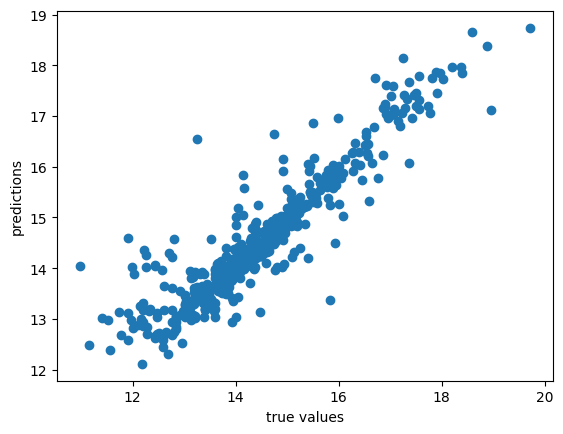

-------------------------------------------------------

5 ) Training: K-Nearest Neighbors Regression
5 : Training: K-Nearest Neighbors Regression
MAE =  0.3785355561227454
RMSE = 0.5973821045176352
R^2 = 0.8049462565038163


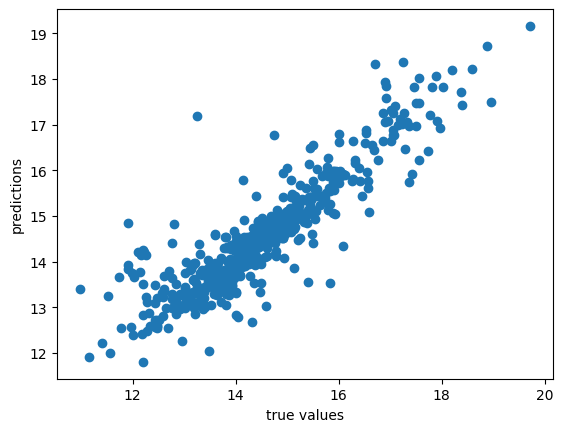

-------------------------------------------------------

6 ) Training: Random Forests Regressor
6 : Training: Random Forests Regressor
MAE =  0.271804651431906
RMSE = 0.5043391652987961
R^2 = 0.8609742446365425


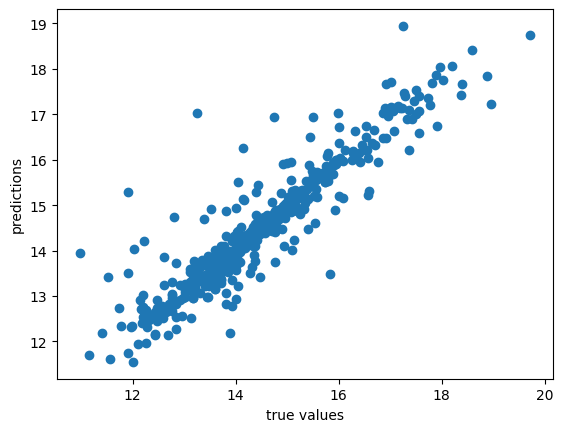

-------------------------------------------------------

7 ) Training: Gradient Boosting Regressor
7 : Training: Gradient Boosting Regressor
MAE =  0.3651840947438948
RMSE = 0.5484851221896965
R^2 = 0.8355705605888534


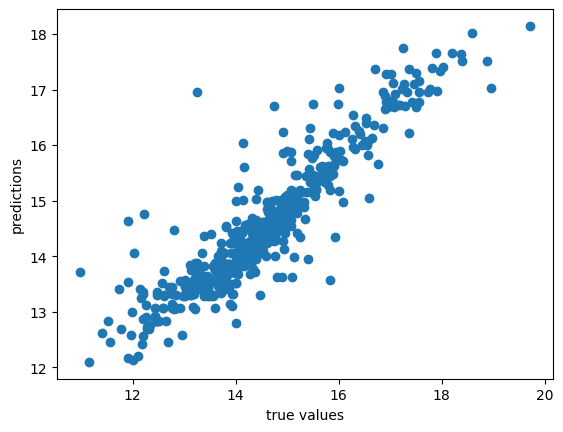

-------------------------------------------------------

8 ) Training: XGBRegressor
8 : Training: XGBRegressor
MAE =  0.26502010031383894
RMSE = 0.453775589905216
R^2 = 0.8874534639637984


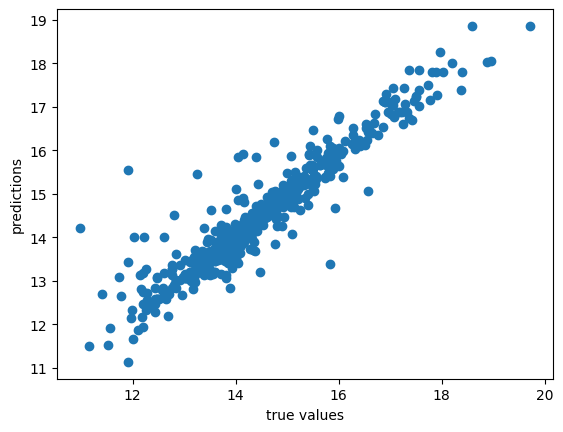

-------------------------------------------------------

9 ) Training: CatBoost
9 : Training: CatBoost
MAE =  0.2694483830011786
RMSE = 0.45828977182022357
R^2 = 0.8852030889780846


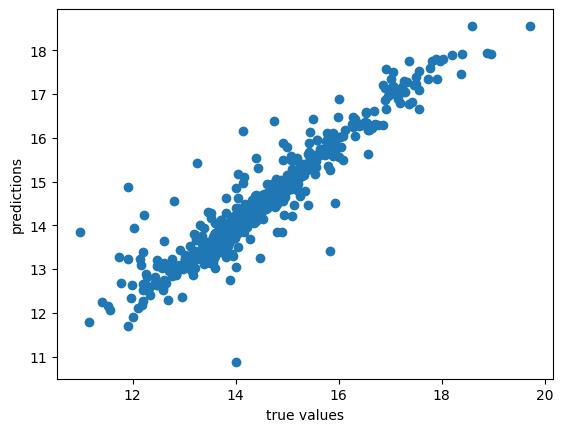

-------------------------------------------------------



In [40]:
#train_test_split
i=1
y_pred=0
#Evaluation the models
for name, model in models.items():
    print(i,')',f"Training: {name}")
    model.fit(X_train_encoded, y_train)  # Train the model
    y_pred = model.predict(X_test_encoded)  # Predict the test set
    MAE = mean_absolute_error(y_test, y_pred)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
    R2 = r2_score(y_test, y_pred)
    print(i,':',f"Training: {name}")
    print(f"MAE =  {MAE}")
    print(f"RMSE = {RMSE}")
    print(f"R^2 = {R2}")
    plt.plot(y_test, y_pred, 'o')
    plt.xlabel('true values')
    plt.ylabel('predictions')
    plt.show()
    print("-------------------------------------------------------")
    print()
    i=i+1

###OrdinalEncoder

In [41]:
from sklearn.preprocessing import OrdinalEncoder
X_train_encoded2 = X_train.copy()
X_test_encoded2 = X_test.copy()
X_train_encoded2['streetwidth'] = np.log(X_train_encoded2['streetwidth'])
X_test_encoded2['streetwidth'] = np.log(X_test_encoded2['streetwidth'])
X_train_encoded2['size'] = np.log(X_train_encoded2['size'])
X_test_encoded2['size'] = np.log(X_test_encoded2['size'])


cols = ['mainlocation','neighborhood','frontage','purpose']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_encoded2[cols] = encoder.fit_transform(X_train_encoded2[cols])
X_test_encoded2[cols] = encoder.transform(X_test_encoded2[cols])

1 ) Training: linear regression
1 : Training: linear regression
MAE =  0.6617161175140989
RMSE = 0.8487448423279389
R^2 = 0.6062648666100018


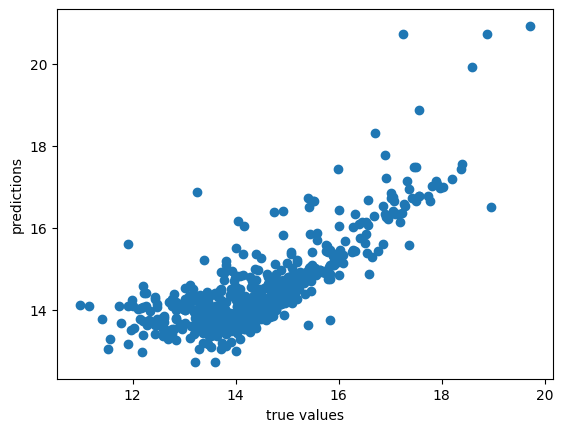

-------------------------------------------------------

2 ) Training: Ridge Regression
2 : Training: Ridge Regression
MAE =  0.6617304978359193
RMSE = 0.8487398952998529
R^2 = 0.606269456477273


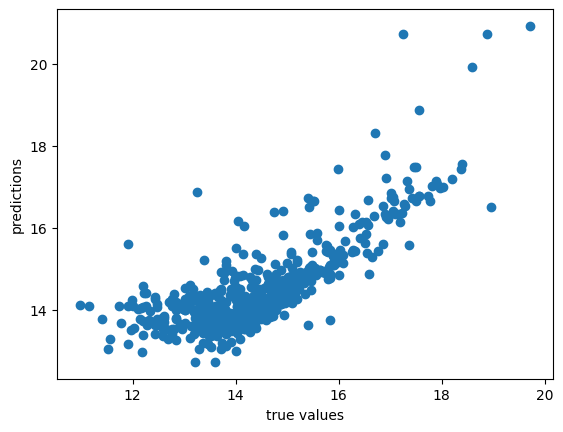

-------------------------------------------------------

3 ) Training: Lasso Regression
3 : Training: Lasso Regression
MAE =  0.9967385418617669
RMSE = 1.311863878215896
R^2 = 0.05935138399016138


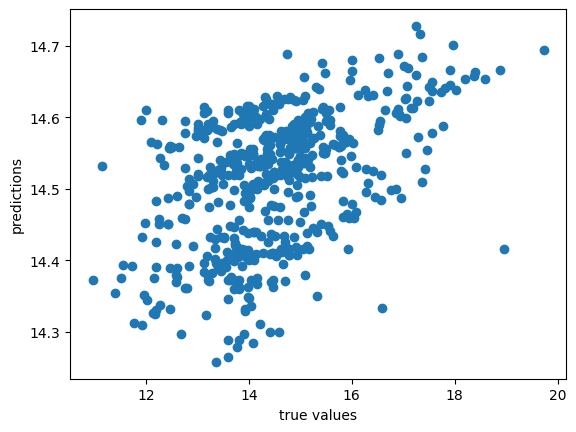

-------------------------------------------------------

4 ) Training: Support Vector Regression (SVR)
4 : Training: Support Vector Regression (SVR)
MAE =  0.9144340105131985
RMSE = 1.2161998621188168
R^2 = 0.1915377007420319


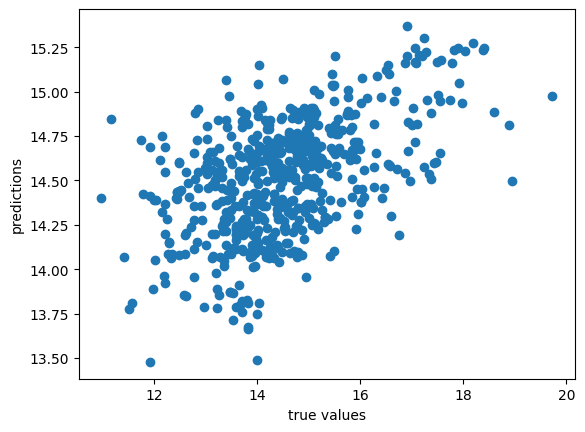

-------------------------------------------------------

5 ) Training: K-Nearest Neighbors Regression
5 : Training: K-Nearest Neighbors Regression
MAE =  0.5358313471920964
RMSE = 0.8609223184491261
R^2 = 0.5948854832339197


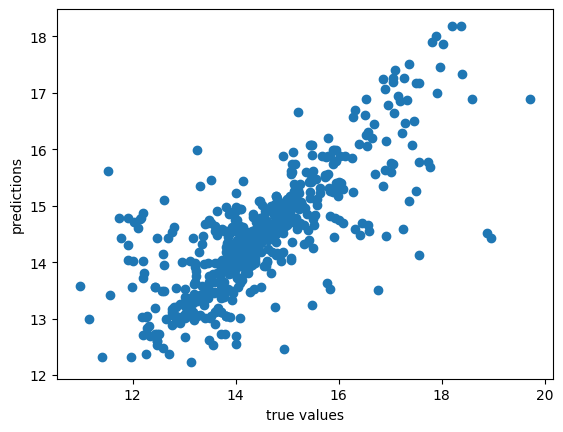

-------------------------------------------------------

6 ) Training: Random Forests Regressor
6 : Training: Random Forests Regressor
MAE =  0.2919698243172378
RMSE = 0.512651380316351
R^2 = 0.8563538022726489


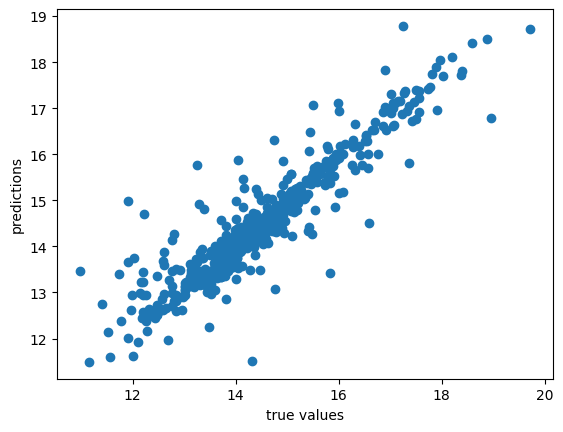

-------------------------------------------------------

7 ) Training: Gradient Boosting Regressor
7 : Training: Gradient Boosting Regressor
MAE =  0.3655241676701255
RMSE = 0.56526792517537
R^2 = 0.8253540338859566


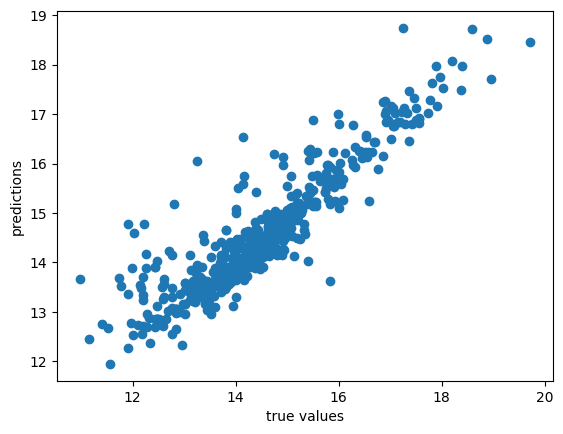

-------------------------------------------------------

8 ) Training: XGBRegressor
8 : Training: XGBRegressor
MAE =  0.2803943635314028
RMSE = 0.4981901818425502
R^2 = 0.8643436269507695


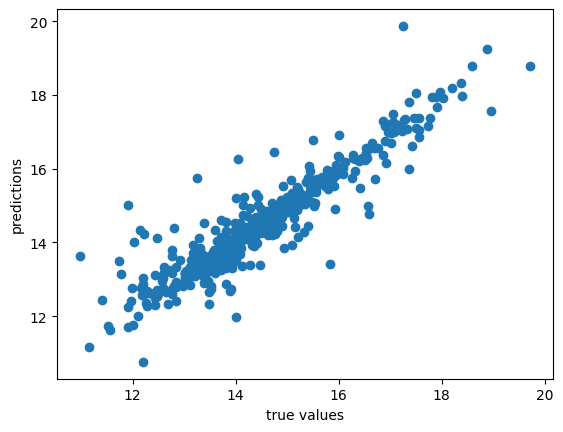

-------------------------------------------------------

9 ) Training: CatBoost
9 : Training: CatBoost
MAE =  0.2842869937871627
RMSE = 0.4983054956504413
R^2 = 0.8642808201596113


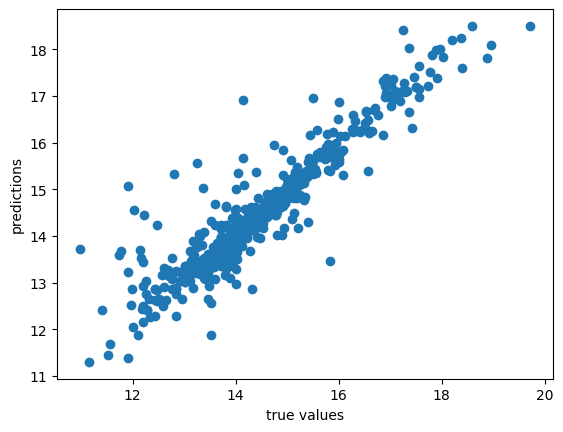

-------------------------------------------------------



In [42]:
i=1
y_pred = 0
#Evaluation the models
for name, model in models.items():
    print(i,')',f"Training: {name}")
    model.fit(X_train_encoded2, y_train)  # Train the model
    y_pred = model.predict(X_test_encoded2)  # Predict the test set
    MAE = mean_absolute_error(y_test, y_pred)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
    R2 = r2_score(y_test, y_pred)
    print(i,':',f"Training: {name}")
    print(f"MAE =  {MAE}")
    print(f"RMSE = {RMSE}")
    print(f"R^2 = {R2}")
    plt.plot(y_test, y_pred, 'o')
    plt.xlabel('true values')
    plt.ylabel('predictions')
    plt.show()
    print("-------------------------------------------------------")
    print()
    i=i+1

## k-folds

###One_Hot_encoding

In [43]:
X_copy = X.copy()
y_copy = y.copy()
X_copy = pd.get_dummies(X_copy)
X_copy['streetwidth'] = np.log(X_copy['streetwidth'])
X_copy['size'] = np.log(X_copy['size'])
y_copy = np.log(y_copy)

1 : Training: linear regression
MAE =  0.2546353769065888
RMSE = 0.49856915181190753
R^2 = 0.8632914207569391


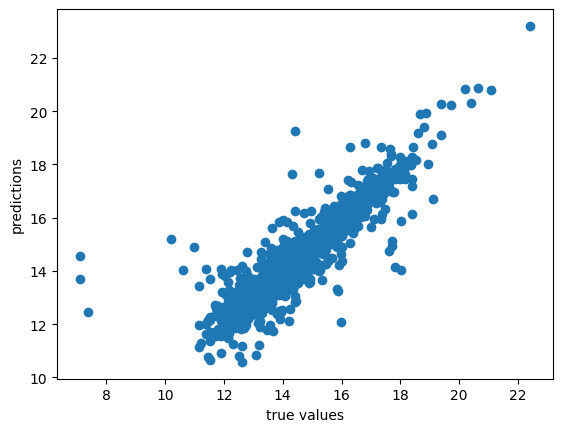

-------------------------------------------------------

2 : Training: Ridge Regression
MAE =  0.2556563568044634
RMSE = 0.48428396422083986
R^2 = 0.8710132381867985


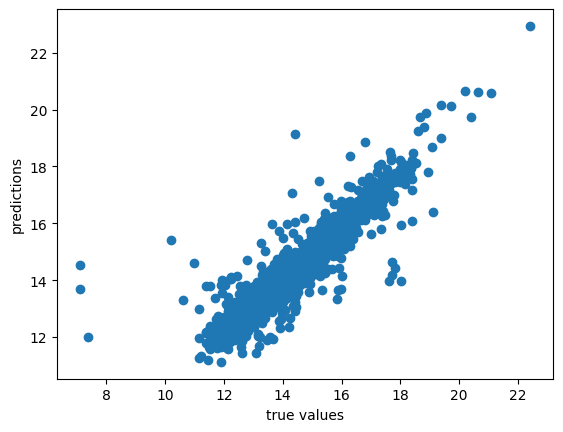

-------------------------------------------------------

3 : Training: Lasso Regression
MAE =  0.9916378001235265
RMSE = 1.3114186425454357
R^2 = 0.05413823815370988


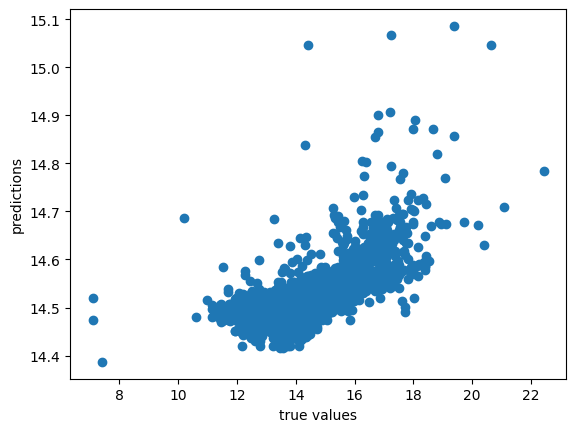

-------------------------------------------------------

4 : Training: Support Vector Regression (SVR)
MAE =  0.3131067596358864
RMSE = 0.5785585377845021
R^2 = 0.8159060245952703


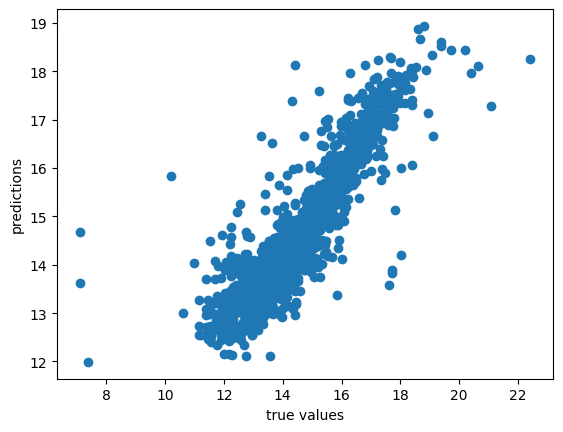

-------------------------------------------------------

5 : Training: K-Nearest Neighbors Regression
MAE =  0.412386644458388
RMSE = 0.6802772624046564
R^2 = 0.745482954526204


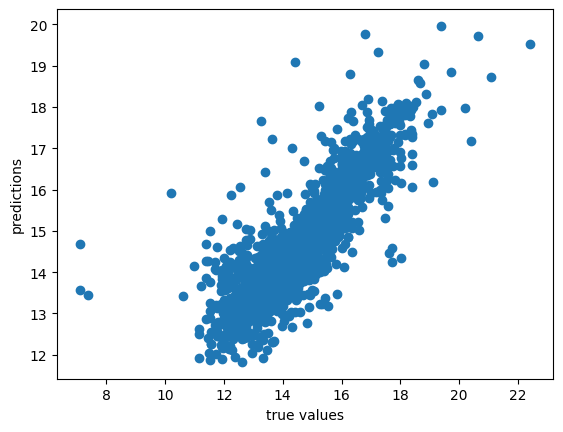

-------------------------------------------------------

6 : Training: Random Forests Regressor
MAE =  0.28523354115552646
RMSE = 0.5687680846000985
R^2 = 0.8220838385952058


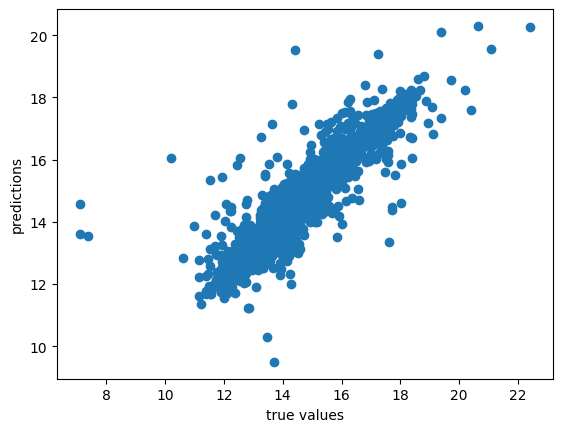

-------------------------------------------------------

7 : Training: Gradient Boosting Regressor
MAE =  0.3721806784379548
RMSE = 0.6054768508898984
R^2 = 0.7983770106828451


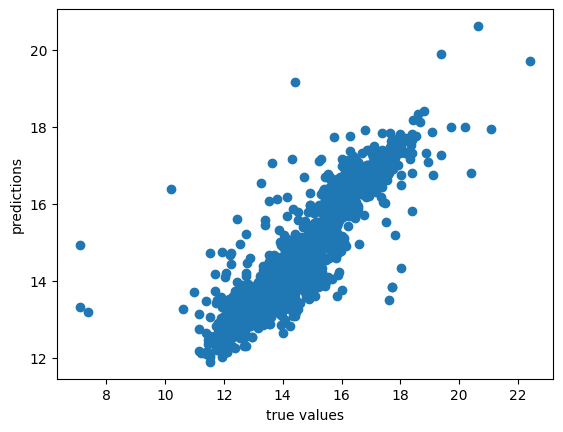

-------------------------------------------------------

8 : Training: XGBRegressor
MAE =  0.281640378712195
RMSE = 0.5555904066441301
R^2 = 0.8302325447321964


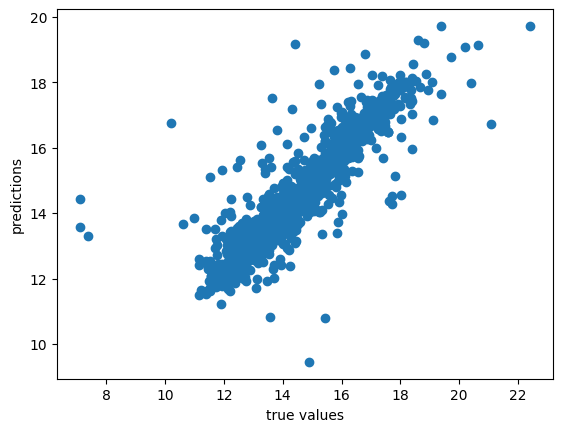

-------------------------------------------------------

9 : Training: CatBoost
MAE =  0.2849280121648538
RMSE = 0.5343977983448014
R^2 = 0.8429368573506987


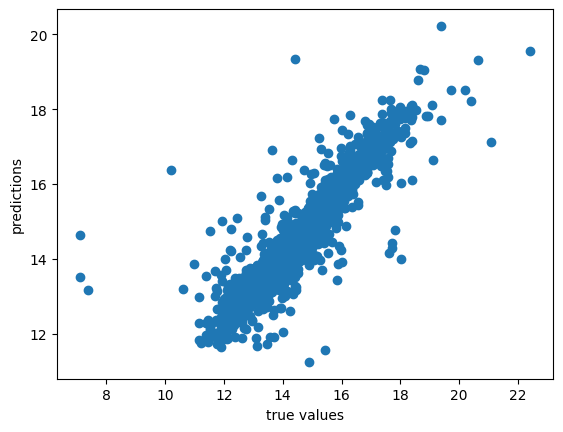

-------------------------------------------------------



In [44]:
kf=KFold(random_state=24, shuffle=True)

i=1
y_pred = 0
for name, model in models.items():
    y_pred = cross_val_predict(model, X_copy, y_copy, cv=kf)
    MAE = mean_absolute_error(y_copy, y_pred)
    RMSE = np.sqrt(mean_squared_error(y_copy, y_pred))
    R2 = r2_score(y_copy, y_pred)
    print(i,':',f"Training: {name}")
    print(f"MAE =  {MAE}")
    print(f"RMSE = {RMSE}")
    print(f"R^2 = {R2}")
    plt.plot(y_copy, y_pred, 'o')
    plt.xlabel('true values')
    plt.ylabel('predictions')
    plt.show()
    print("-------------------------------------------------------")
    print()
    i=i+1

###Label Encoding

In [45]:
X_copy1 = X.copy()
y_copy1 = y.copy()


In [46]:
# log transform
X_copy1['streetwidth'] = np.log1p(X_copy1['streetwidth'])
X_copy1['size'] = np.log(X_copy1['size'])
y_copy1 = np.log(y_copy1)

cols = ['mainlocation','neighborhood','frontage','purpose']

encoders = {}

for col in cols:
    le = LabelEncoder()
    X_copy1[col] = le.fit_transform(X_copy1[col])
    encoders[col] = le

1 : Training: linear regression
MAE =  0.6799166557502135
RMSE = 0.8850620552881646
R^2 = 0.5691834224839452


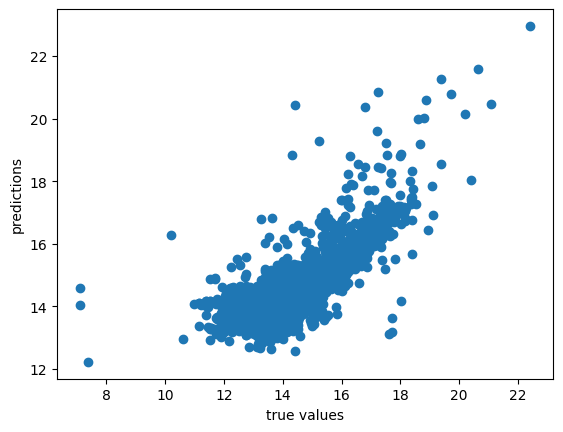

-------------------------------------------------------

2 : Training: Ridge Regression
MAE =  0.6799297774118035
RMSE = 0.8850599227177656
R^2 = 0.5691854985995537


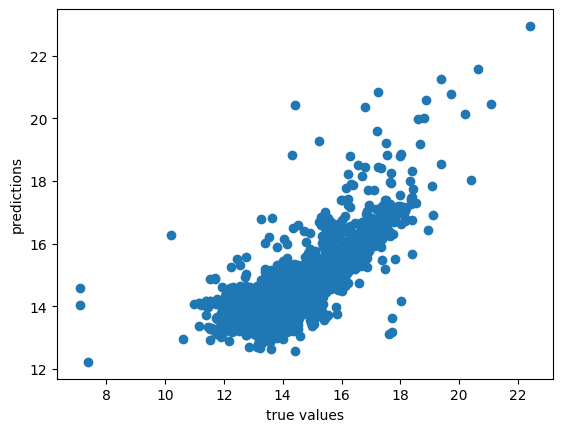

-------------------------------------------------------

3 : Training: Lasso Regression
MAE =  0.9846434541125996
RMSE = 1.3037712913022002
R^2 = 0.06513739097680338


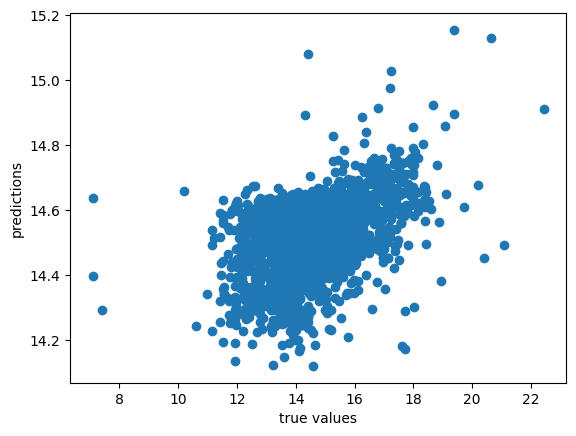

-------------------------------------------------------

4 : Training: Support Vector Regression (SVR)
MAE =  0.9256144681149692
RMSE = 1.2347300858112469
R^2 = 0.16152711383091534


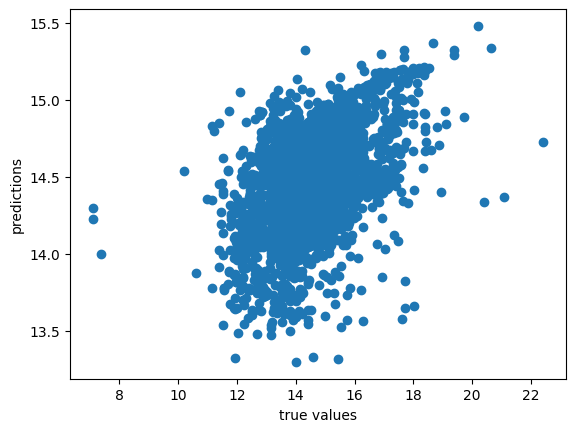

-------------------------------------------------------

5 : Training: K-Nearest Neighbors Regression
MAE =  0.5272442409166715
RMSE = 0.8883081882593992
R^2 = 0.5660174241264844


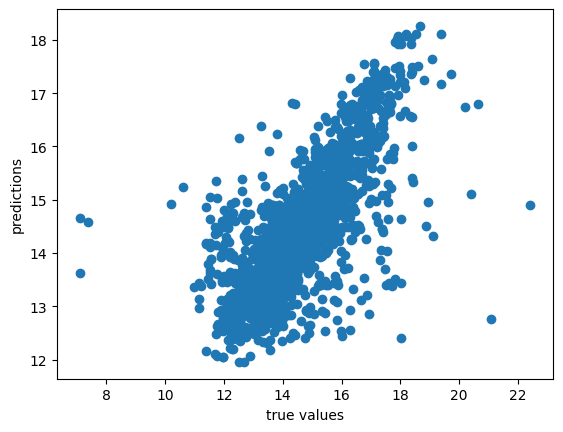

-------------------------------------------------------

6 : Training: Random Forests Regressor
MAE =  0.3129395543543088
RMSE = 0.5919353300983454
R^2 = 0.807294776739846


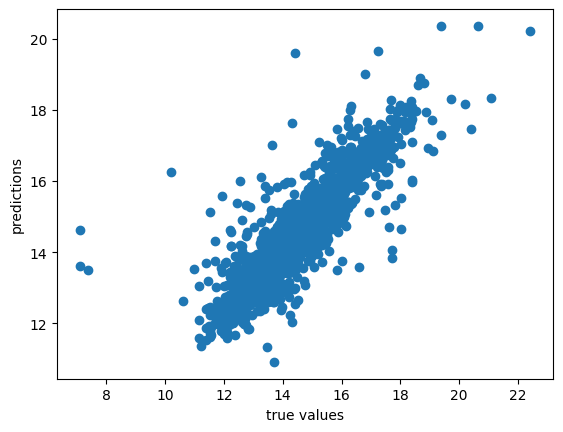

-------------------------------------------------------

7 : Training: Gradient Boosting Regressor
MAE =  0.37155184617742587
RMSE = 0.6017950302050102
R^2 = 0.8008216381172889


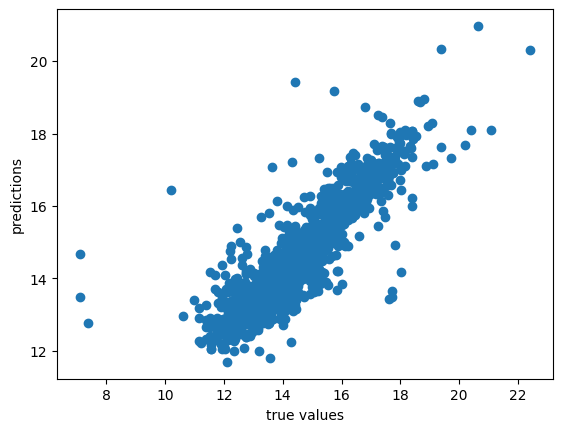

-------------------------------------------------------

8 : Training: XGBRegressor
MAE =  0.2922058881320636
RMSE = 0.5923592182036729
R^2 = 0.8070186834049244


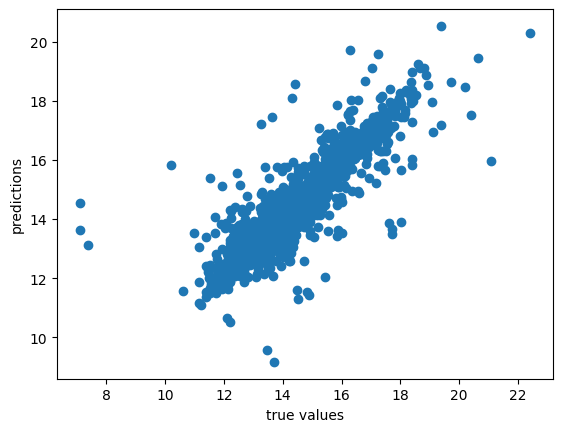

-------------------------------------------------------

9 : Training: CatBoost
MAE =  0.28004286098446235
RMSE = 0.5302097329013102
R^2 = 0.8453890125634836


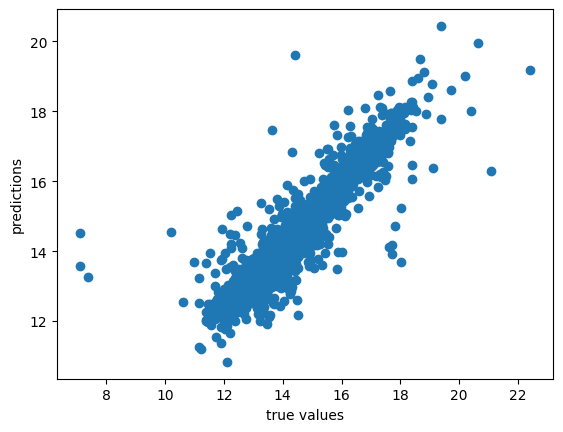

-------------------------------------------------------



In [47]:
kf=KFold(random_state=24, shuffle=True)
y_pred = 0
i=1
for name, model in models.items():
    y_pred = cross_val_predict(model, X_copy1, y_copy1, cv=kf)
    MAE = mean_absolute_error(y_copy1, y_pred)
    RMSE = np.sqrt(mean_squared_error(y_copy1, y_pred))
    R2 = r2_score(y_copy1, y_pred)
    print(i,':',f"Training: {name}")
    print(f"MAE =  {MAE}")
    print(f"RMSE = {RMSE}")
    print(f"R^2 = {R2}")
    plt.plot(y_copy1, y_pred, 'o')
    plt.xlabel('true values')
    plt.ylabel('predictions')
    plt.show()
    print("-------------------------------------------------------")
    print()
    i=i+1

# At the end i found Ridge with train test split and one hot encoding give me the best result.